In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as lines
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
df=pd.read_csv('SampleSuperstore.csv',encoding='latin1')
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9993 non-null   object 
 1   Segment       9993 non-null   object 
 2   Country       9993 non-null   object 
 3   City          9993 non-null   object 
 4   State         9993 non-null   object 
 5   Postal Code   9993 non-null   int64  
 6   Region        9993 non-null   object 
 7   Category      9993 non-null   object 
 8   Sub-Category  9993 non-null   object 
 9   Sales         9993 non-null   float64
 10  Quantity      9993 non-null   int64  
 11  Discount      9993 non-null   float64
 12  Profit        9993 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.0+ KB


In [4]:
df.duplicated().sum()

np.int64(17)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [7]:
df['Ship Mode'].value_counts().to_frame()

,count
Ship Mode,
Standard Class,5955
Second Class,1942
First Class,1537
Same Day,542


In [8]:
df['Segment'].value_counts().to_frame()

,count
Segment,
Consumer,5182
Corporate,3015
Home Office,1779


In [9]:
df['Country'].value_counts().to_frame()

,count
Country,
United States,9976


In [10]:
df['City'].value_counts().to_frame()

,count
City,
New York City,914
Los Angeles,746
Philadelphia,536
San Francisco,506
Seattle,424
...,...
Abilene,1
Montebello,1
Kissimmee,1


In [11]:
df['Region'].value_counts().to_frame()


,count
Region,
West,3192
East,2845
Central,2319
South,1620


In [12]:
df['Category'].value_counts().to_frame()

,count
Category,
Office Supplies,6011
Furniture,2118
Technology,1847


In [13]:
df['Sub-Category'].value_counts().to_frame()

,count
Sub-Category,
Binders,1522
Paper,1359
Furnishings,956
Phones,889
Storage,846
Art,795
Accessories,775
Chairs,615
Appliances,465


In [14]:
df.drop(columns='Postal Code',inplace=True)

In [15]:
df.drop(columns='Country',inplace=True)
df.describe()

,Sales,Quantity,Discount,Profit
count,9976.000000,9976.000000,9976.000000,9976.000000
mean,230.147597,3.790898,0.156294,28.685693
std,623.752659,2.226696,0.206460,234.469173
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.295000,2.000000,0.000000,1.725850
50%,54.804000,3.000000,0.200000,8.666500
75%,209.970000,5.000000,0.200000,29.366000
max,22638.480000,14.000000,0.800000,8399.976000


<Axes: >

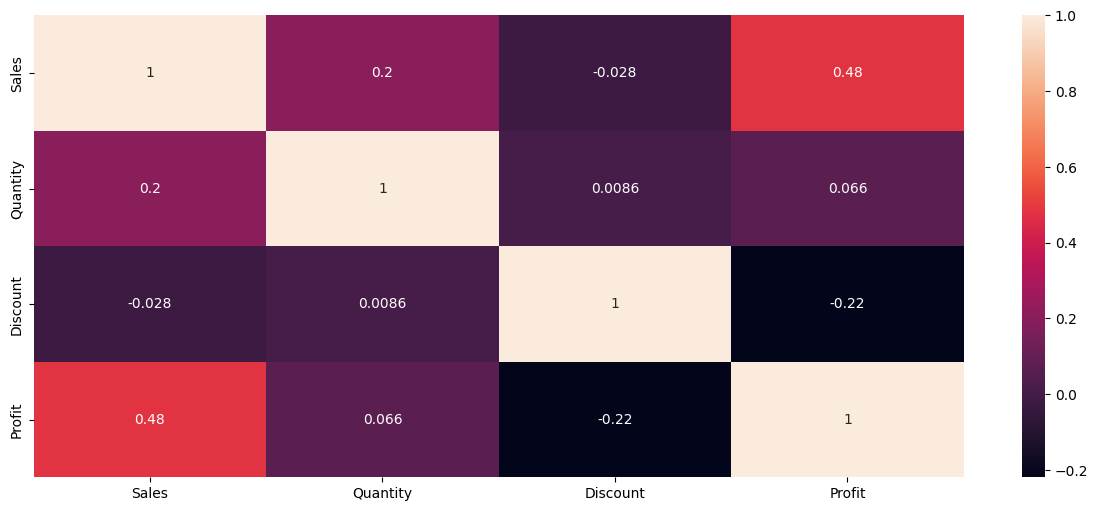

In [16]:
plt.figure(figsize=(15,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [17]:
# ANALYSIS BASED ON CATEGORY AND SUB-CATEGORY

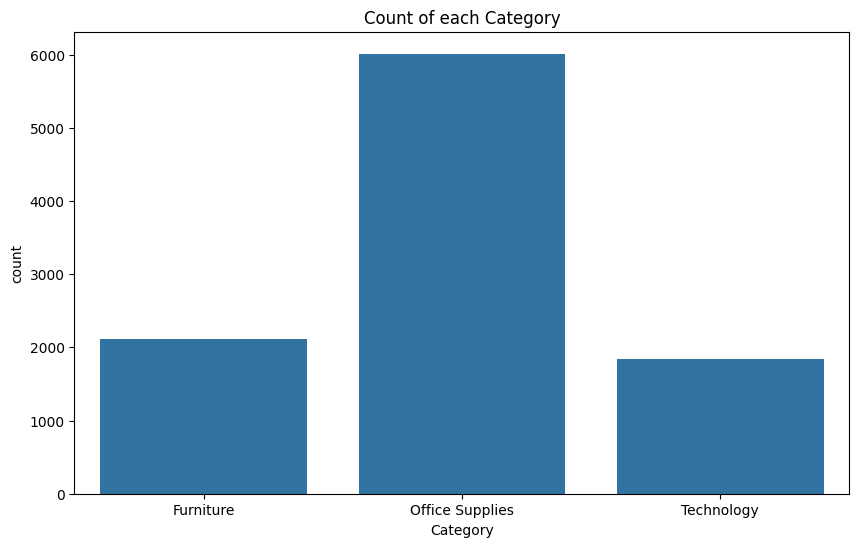

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(x='Category',data = df)
plt.title("Count of each Category")
plt.show();


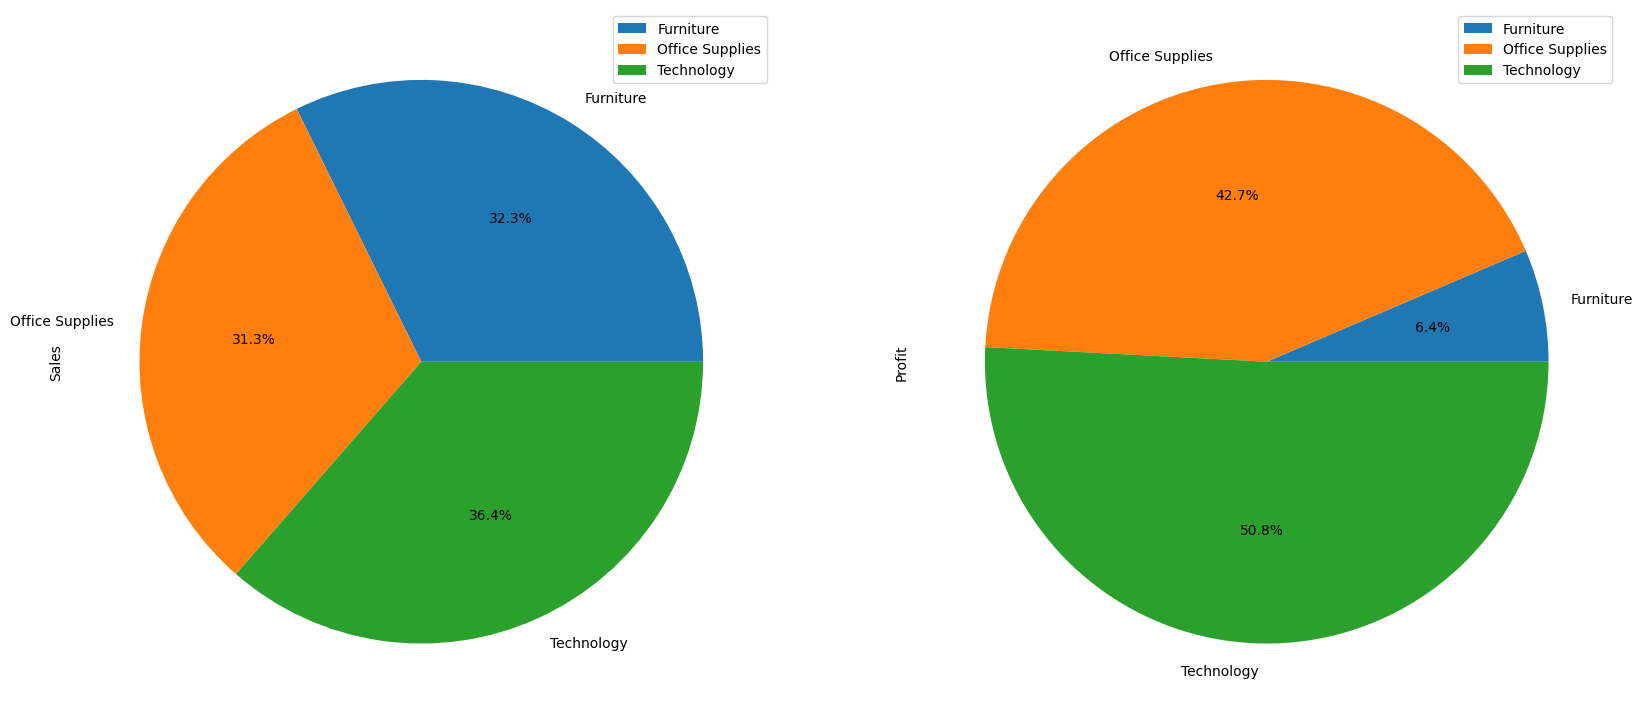

In [19]:
df_categ = df.groupby(['Category']).sum()[['Profit','Sales']]
df_categ[['Sales','Profit']].plot.pie(subplots=True,figsize=(20,10),autopct='%1.1f%%');
 

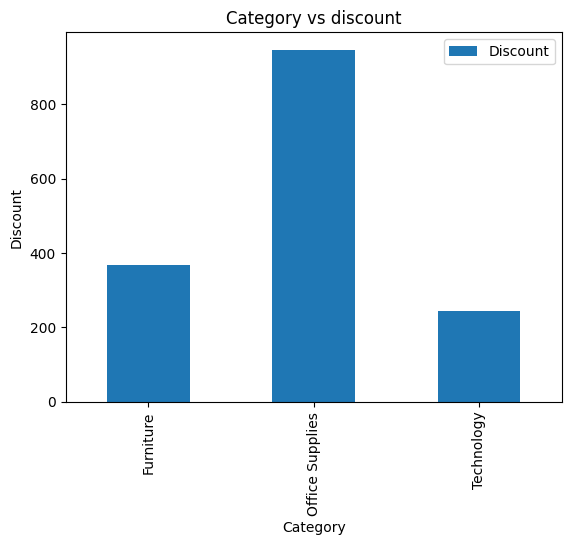

In [20]:
df.groupby(['Category']).sum()[['Discount']].plot.bar()
plt.title("Category vs discount")
plt.ylabel('Discount');

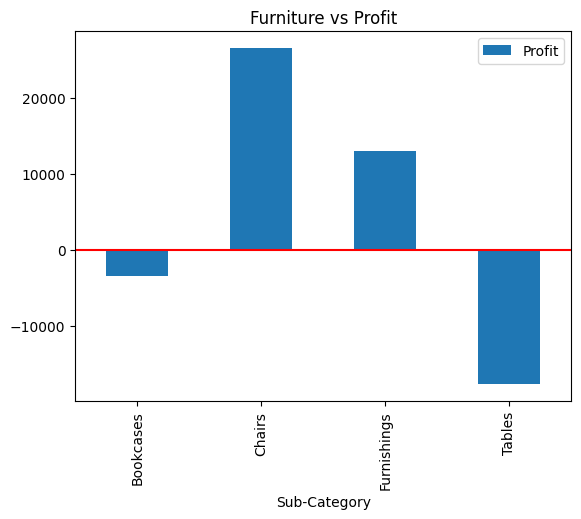

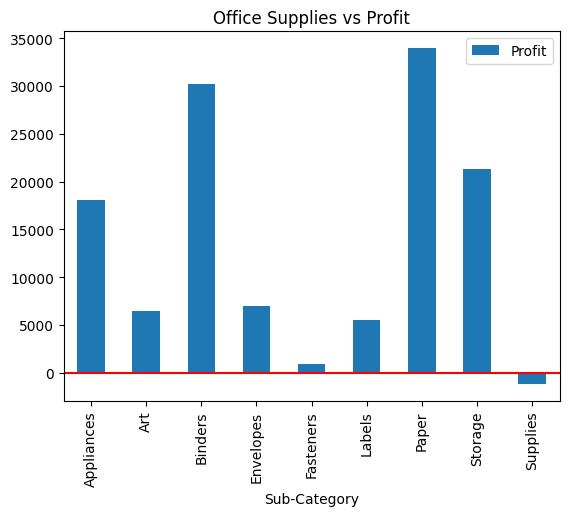

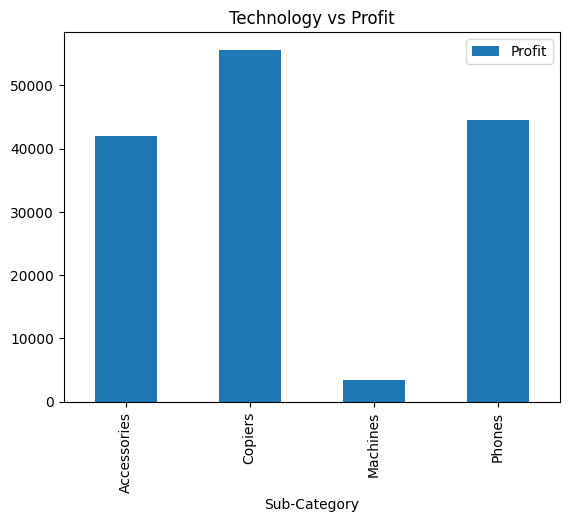

In [21]:
df_Furniture=df.set_index(['Category']).loc['Furniture']
df_Office=df.set_index(['Category']).loc['Office Supplies']
df_Technology=df.set_index(['Category']).loc['Technology']
df_Furniture[['Sub-Category','Profit']].groupby('Sub-Category').sum().plot.bar(title='Furniture vs Profit')
plt.axhline(0,color ='r')
df_Office[['Sub-Category','Profit']].groupby('Sub-Category').sum().plot.bar(title='Office Supplies vs Profit')
plt.axhline(0,color ='r')

df_Technology[['Sub-Category','Profit']].groupby('Sub-Category').sum().plot.bar(title='Technology vs Profit');
                                                                               
                                                                               

In [22]:
# is there a product that either loses or wins all the time? If so,what exactly is this product?

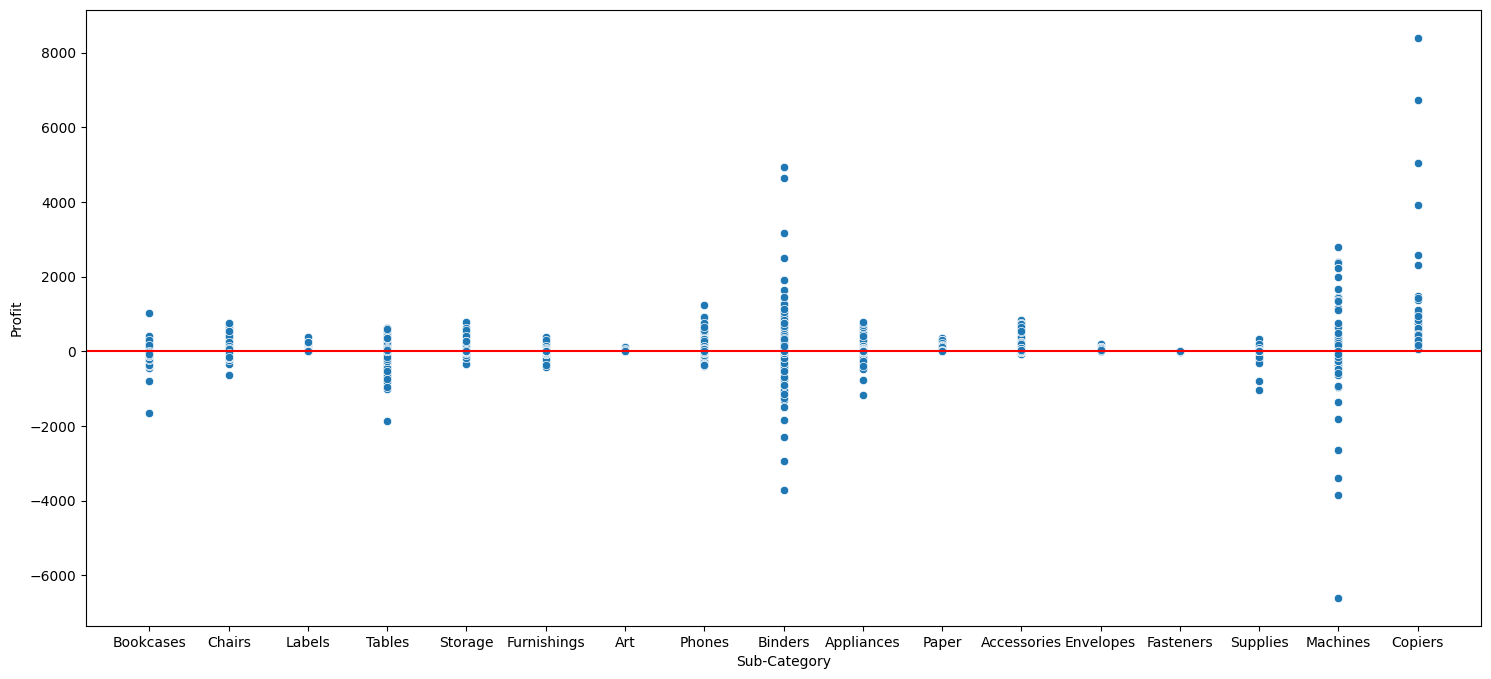

In [23]:
plt.figure(figsize=(18,8))
graph=sns.scatterplot(y='Profit',x='Sub-Category',data=df)
graph.axhline(0,color='r')
plt.show()

In [24]:
# ANALYSIS BASED ON STATE

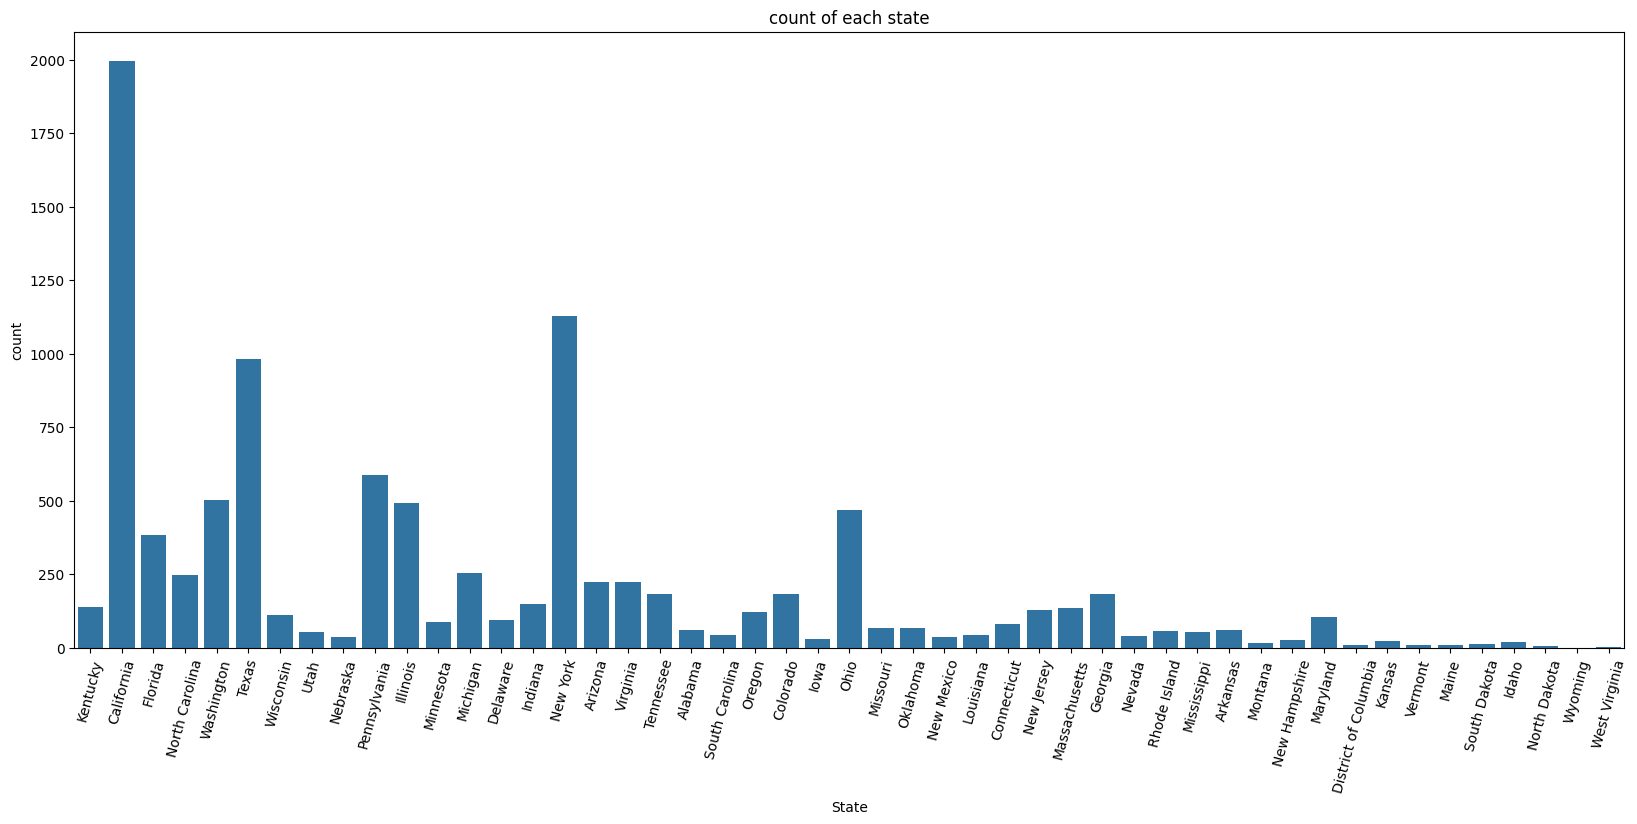

In [25]:
plt.figure(figsize=(20,8))
sns.countplot(data=df,x='State')
plt.xticks(rotation=75)
plt.title('count of each state')
plt.show()

Text(0.5, 1.0, 'State vs Profit')

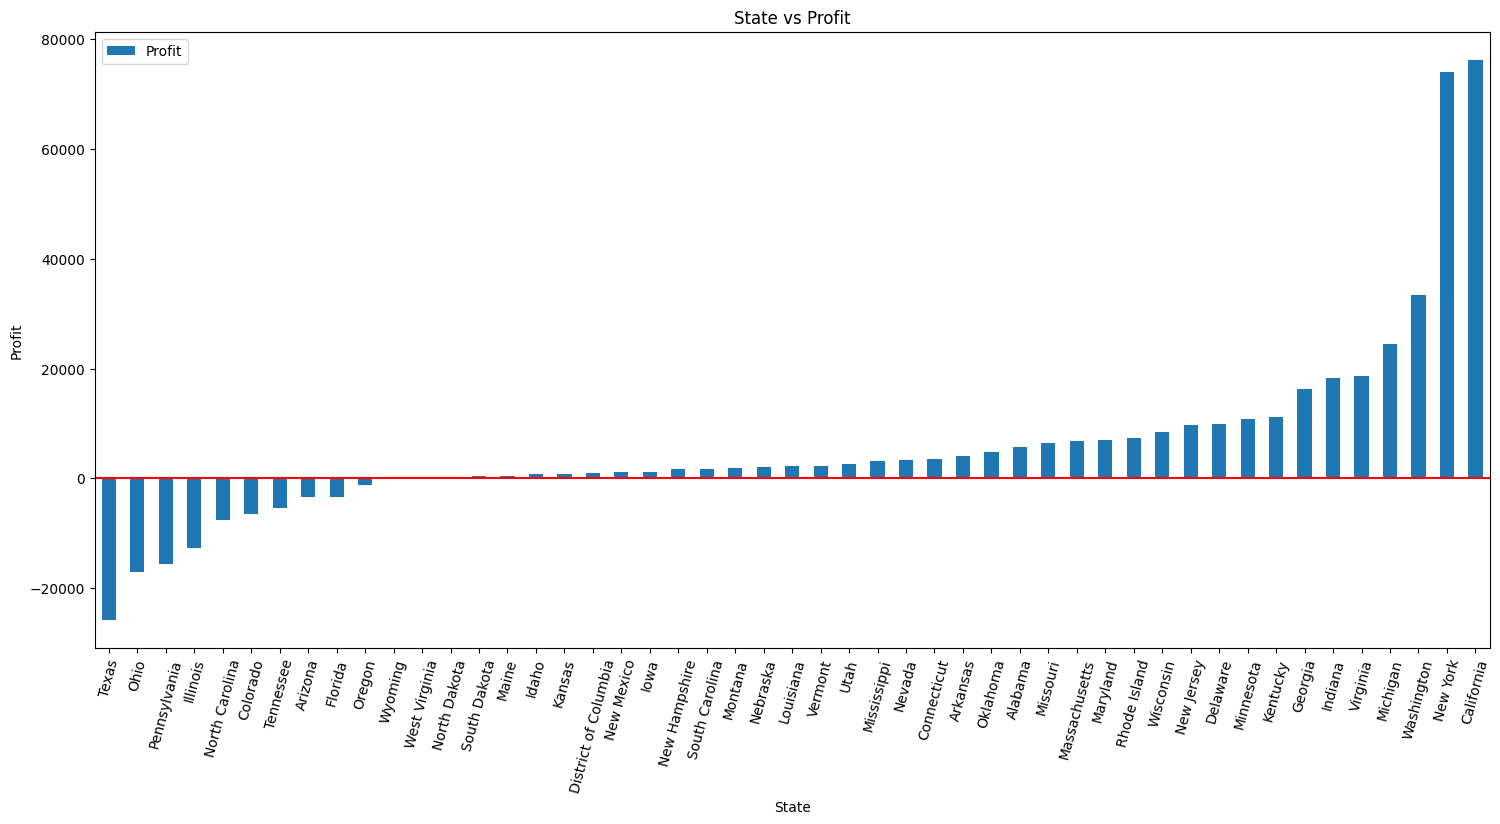

In [26]:
df.groupby(['State']).sum()[['Profit']].sort_values(['Profit']).plot.bar(figsize=(18,8))
plt.ylabel("Profit")
plt.xticks(rotation=75)
plt.axhline(0,color='r')
plt.title('State vs Profit')

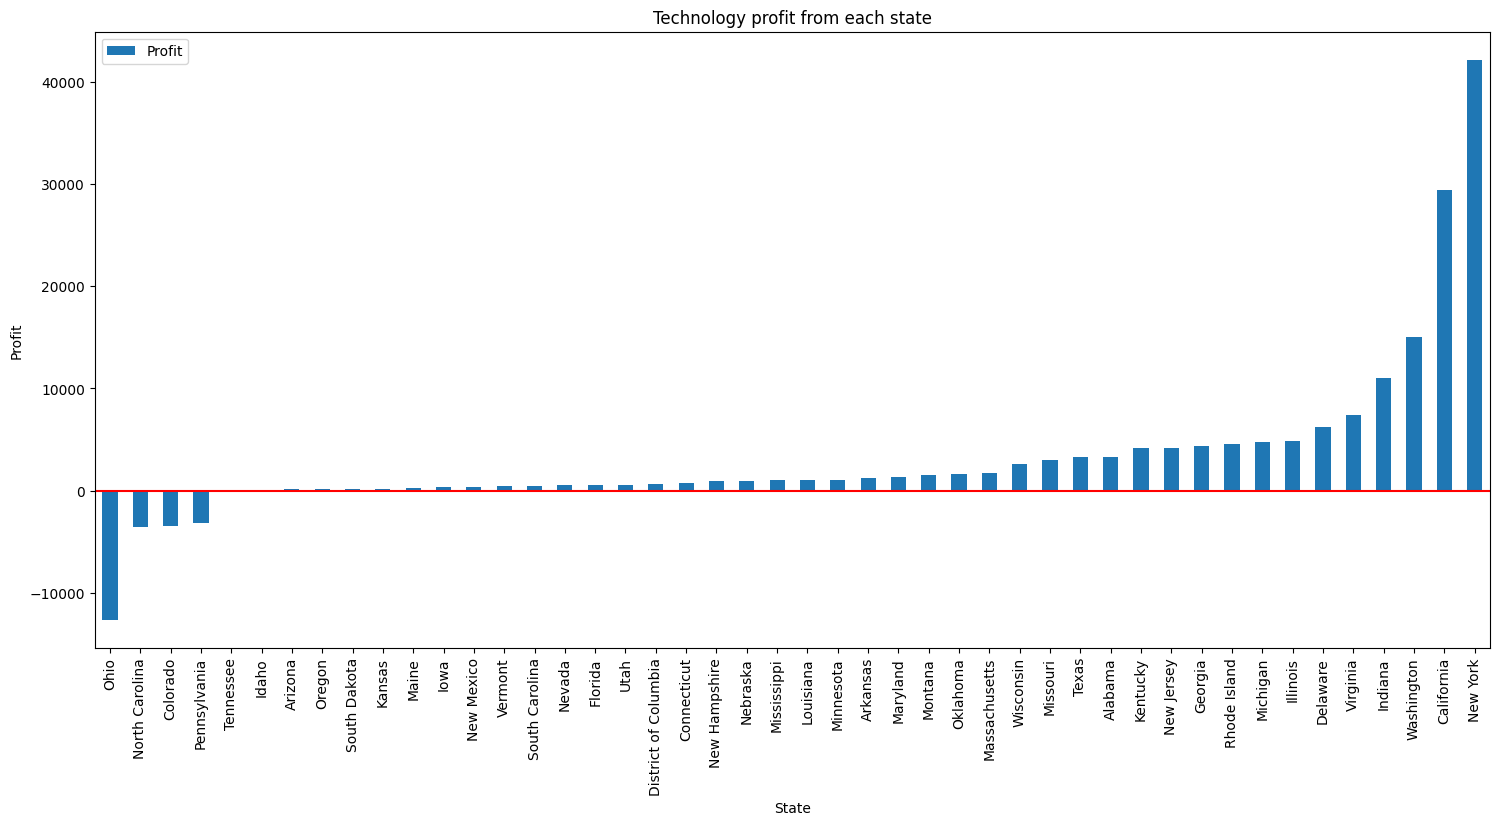

In [27]:
df_Technology.groupby('State').sum()[['Profit']].sort_values('Profit').plot.bar(figsize=(18,8))
    
plt.axhline(0,color='r')
plt.title('Technology profit from each state')
plt.ylabel('Profit');

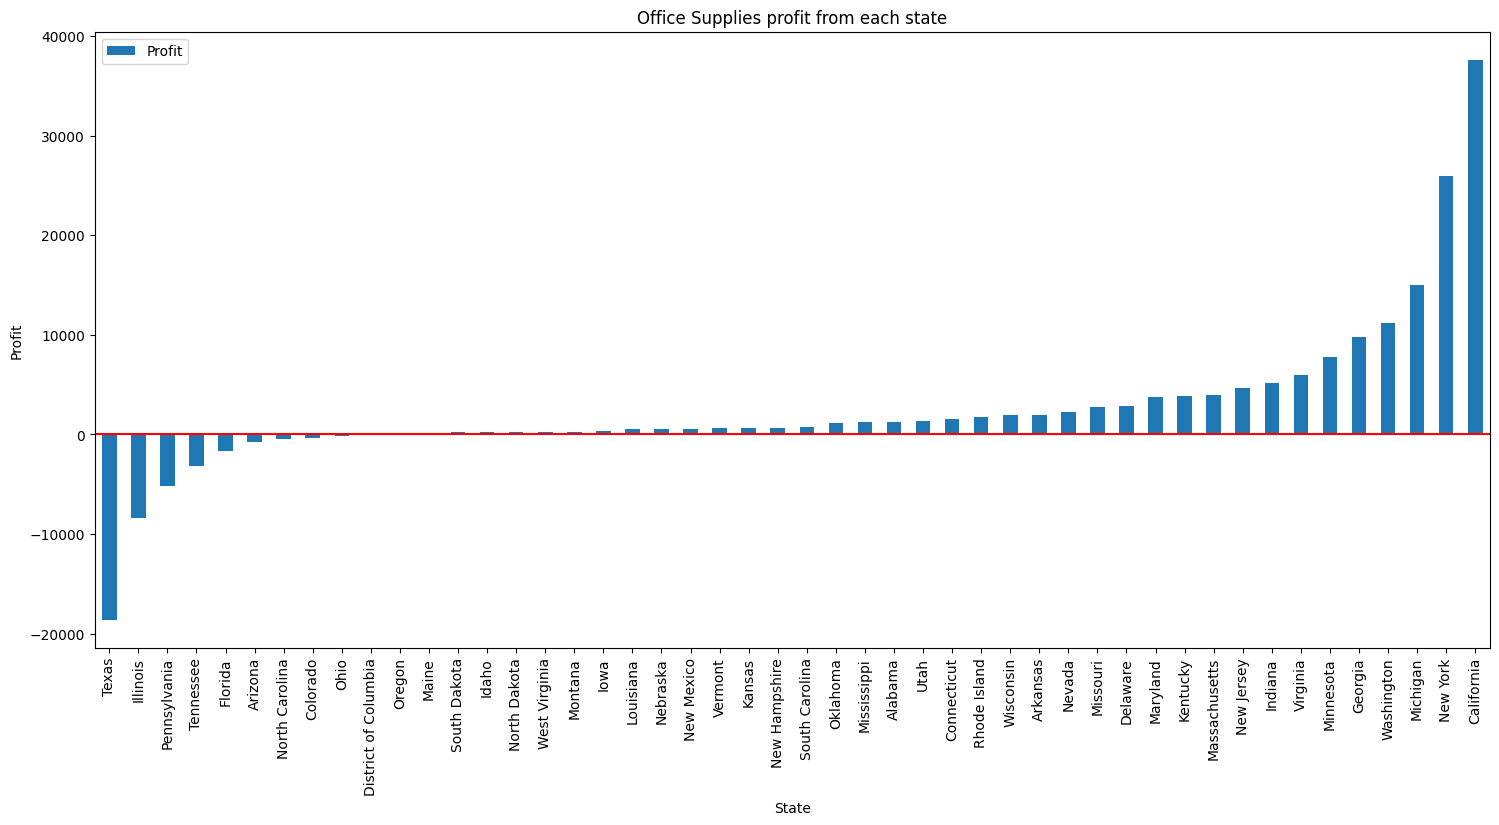

In [28]:
df_Office.groupby('State').sum()[['Profit']].sort_values('Profit').plot.bar(figsize=(18,8))
plt.axhline(0,color='r')
plt.title('Office Supplies profit from each state')
plt.ylabel('Profit');    